In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
df=pd.read_csv("diabetes.csv")
print(df.head())
print(df.info())
print(df.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      172             47             43       19  22.9   
1            3      102             91              8       16  21.9   
2           12      193             66             17       36  19.9   
3           14      106             54             53      126  36.8   
4           10       88             77              6       71  42.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.250   69        0  
1                     0.905   50        0  
2                     0.261   18        1  
3                     2.441   61        1  
4                     2.061   70        0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

In [3]:
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      172             47             43       19  22.9   
1              3      102             91              8       16  21.9   
2             12      193             66             17       36  19.9   
3             14      106             54             53      126  36.8   
4             10       88             77              6       71  42.3   
..           ...      ...            ...            ...      ...   ...   
763            4      114             32             50      157  46.4   
764            4       52            102             10       42  36.8   
765            2      191             37             38      292  49.1   
766           11      169             99              5      247  31.3   
767            8      117             70             14       31  44.7   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.250   69        0  
1                  

In [4]:
(df == 0).sum()

Pregnancies                  65
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     262
dtype: int64

In [8]:
cols_with_zero_nan=["Glucose","BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
for col in cols_with_zero_nan:
    df[col]=df[col].replace(0, np.nan)
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      172             47             43       19  22.9   
1              3      102             91              8       16  21.9   
2             12      193             66             17       36  19.9   
3             14      106             54             53      126  36.8   
4             10       88             77              6       71  42.3   
..           ...      ...            ...            ...      ...   ...   
763            4      114             32             50      157  46.4   
764            4       52            102             10       42  36.8   
765            2      191             37             38      292  49.1   
766           11      169             99              5      247  31.3   
767            8      117             70             14       31  44.7   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.250   69        0  
1                  

In [16]:
df["Glucose"].fillna(df["Glucose"].median())
df["BloodPressure"].fillna(df["BloodPressure"].median())
df["SkinThickness"].fillna(df["SkinThickness"].median())
df["Insulin"].fillna(df["Insulin"].median())
df["BMI"].fillna(df["BMI"].median())
df["DiabetesPedigreeFunction"].fillna(df["DiabetesPedigreeFunction"].median())
df["Age"].fillna(df["Age"].median())
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [17]:
print(df.sample(10))

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
494            6       87             55              7       77  23.2   
300           10       85            117             52      104  49.0   
489            7       84            107             20      177  33.2   
373            7      109             61              6      210  22.0   
165            2      101             49             38      204  49.1   
63             8       69             43             44      277  33.3   
37             0      139             86             33      262  30.6   
664            0      105             78             40      114  43.2   
398            0      102             90             20      259  17.4   
196            3      145            116             14      241  35.4   

     DiabetesPedigreeFunction  Age  Outcome  
494                     0.469   18        0  
300                     0.227   64        0  
489                     1.372   42        0  
3

In [20]:
bins = [0, 17, 40, 60, 80, 120]
labels = [
    '0-17 (child)',
    '18-40 (young)',
    '41-60 (adult)',
    '61-80 (senior)',
    '81+ (older)'
]
df['AgeGroup']=pd.cut(df['Age'], bins=bins, labels=labels)

In [21]:
print(df.tail())

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763            4      114             32             50      157  46.4   
764            4       52            102             10       42  36.8   
765            2      191             37             38      292  49.1   
766           11      169             99              5      247  31.3   
767            8      117             70             14       31  44.7   

     DiabetesPedigreeFunction  Age  Outcome        AgeGroup  
763                     0.463   65        1  61-80 (senior)  
764                     1.246   78        0  61-80 (senior)  
765                     1.544   78        1  61-80 (senior)  
766                     1.496   48        0   41-60 (adult)  
767                     1.064   48        1   41-60 (adult)  


In [22]:
df.to_csv('diabets_clean.csv', index= False)

In [11]:
import pandas as pd
df=pd.read_csv('diabets_clean.csv')
from sklearn.preprocessing import StandardScaler
df_scaled=df.copy()
features=df_scaled.drop(['Outcome', 'AgeGroup'], axis=1)
scaler=StandardScaler()
scaled=scaler.fit_transform(features)
df_scaled[features.columns]=scaled
df_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeGroup
0,-0.200615,1.091757,-1.055796,0.725546,-1.677891,-0.974521,-1.477059,1.107168,0,61-80 (senior)
1,-0.888438,-0.497414,0.641837,-1.503076,-1.714478,-1.073794,-0.521284,0.043027,0,41-60 (adult)
2,1.175031,1.568508,-0.322727,-0.930002,-1.470569,-1.272341,-1.461008,-1.749212,1,18-40 (young)
3,1.633580,-0.406604,-0.785718,1.362295,-0.372978,0.405379,1.720047,0.659109,1,61-80 (senior)
4,0.716482,-0.815248,0.101681,-1.630426,-1.043728,0.951383,1.165551,1.163176,0,61-80 (senior)


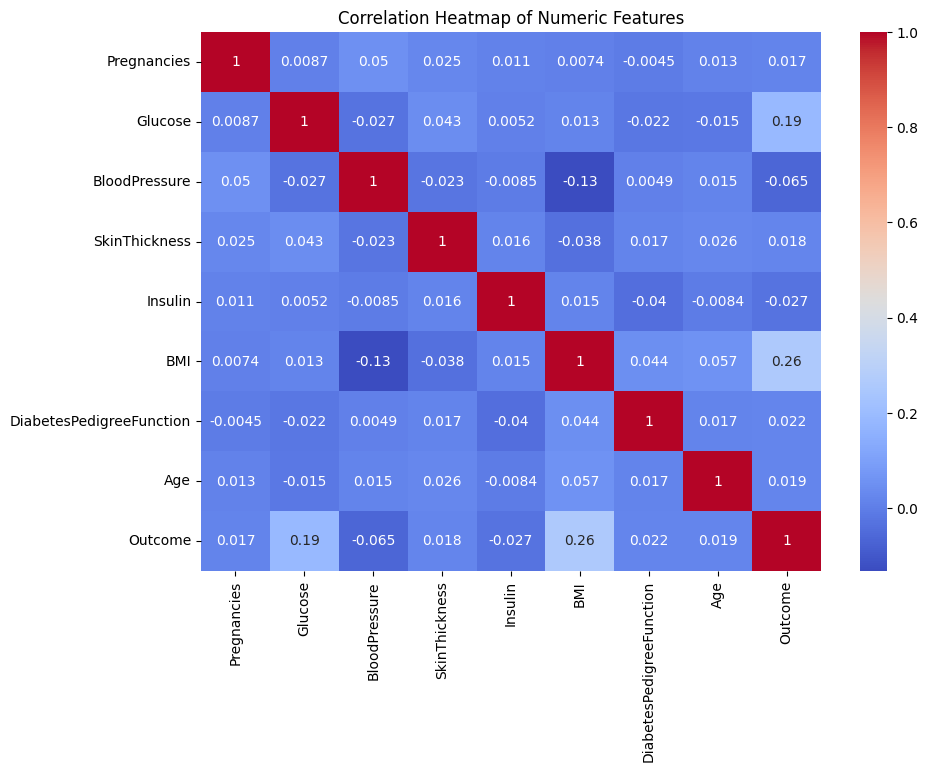

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('diabets_clean.csv')
from sklearn.preprocessing import StandardScaler
df_scaled=df.copy()
features=df_scaled.drop(['Outcome', 'AgeGroup'], axis=1)
scaler=StandardScaler()
scaled=scaler.fit_transform(features)
df_scaled[features.columns]=scaled
numeric_df = df_scaled.drop(columns=['AgeGroup'])
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

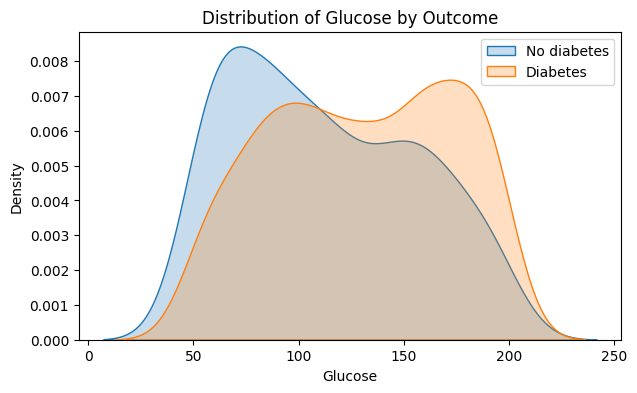

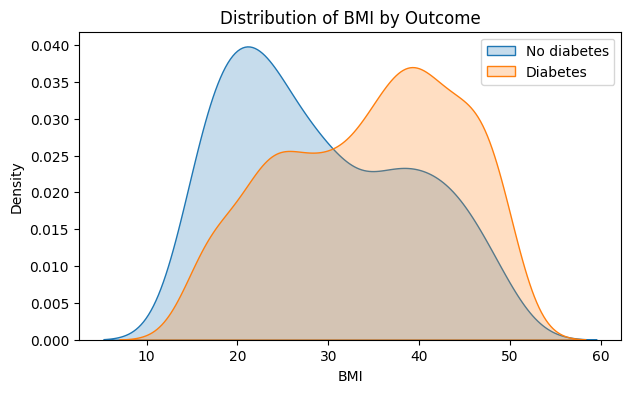

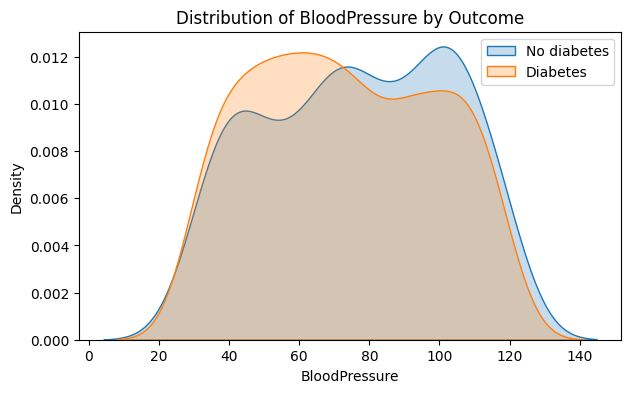

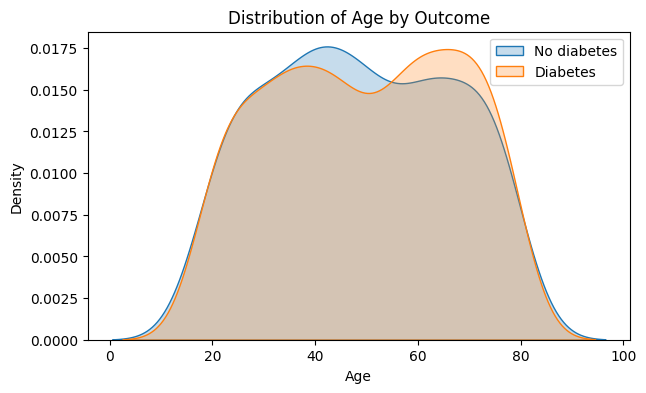

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('diabets_clean.csv')
features_list= ['Glucose', 'BMI', 'BloodPressure', 'Age']
for col in features_list:
    plt.figure(figsize=(7, 4))
    sns.kdeplot(df[df['Outcome']==0][col],label="No diabetes",fill=True) 
    sns.kdeplot(df[df['Outcome']==1][col],label="Diabetes", fill=True) 
    plt.title(f"Distribution of {col} by Outcome")
    plt.legend()
    plt.show()

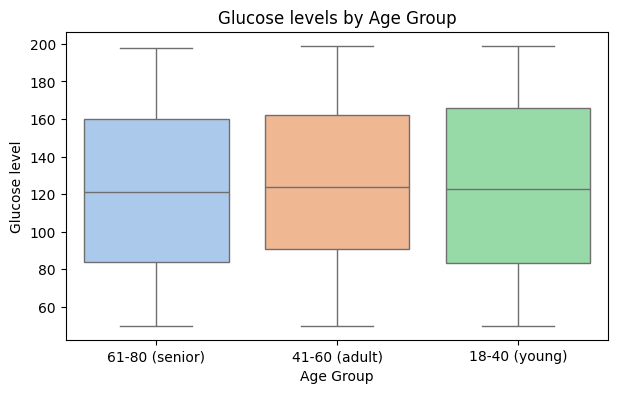

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('diabets_clean.csv')
plt.figure(figsize=(7,4))
sns.boxplot(x='AgeGroup', y='Glucose', hue='AgeGroup', data=df, legend=False, palette='pastel')
plt.title("Glucose levels by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Glucose level")
plt.show()

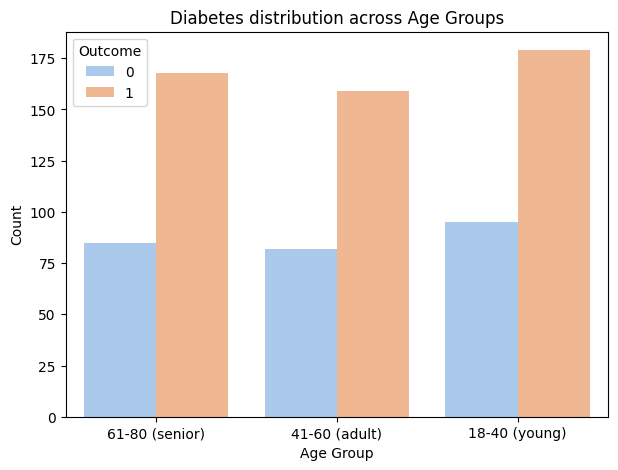

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('diabets_clean.csv')
plt.figure(figsize=(7,5))
sns.countplot(x='AgeGroup', hue='Outcome', data=df, palette='pastel')
plt.title("Diabetes distribution across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

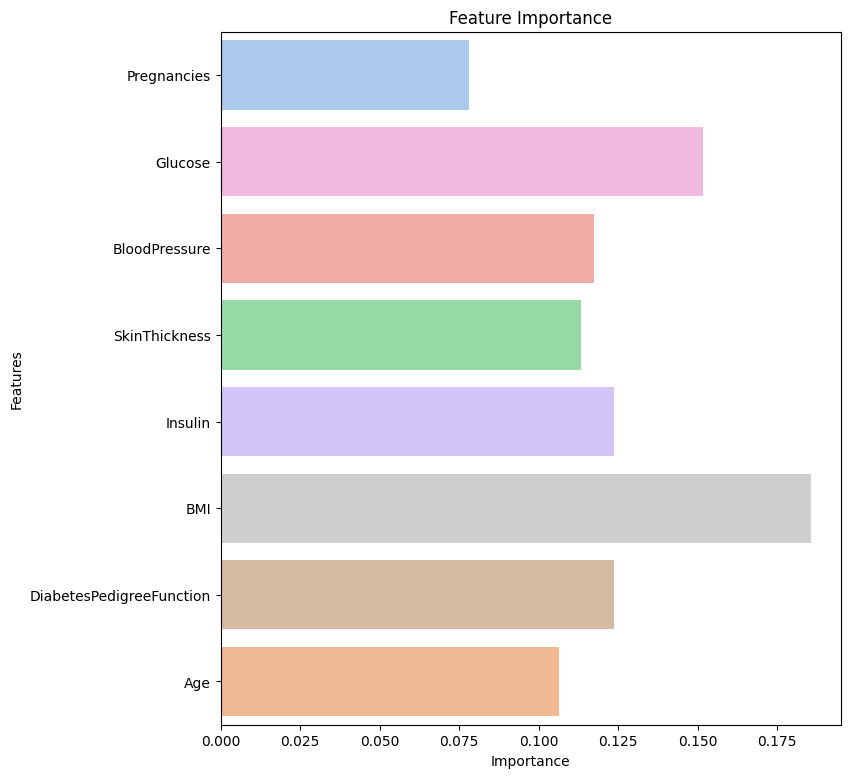

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('diabets_clean.csv')
from sklearn.preprocessing import StandardScaler
df_scaled=df.copy()
features=df_scaled.drop(['Outcome', 'AgeGroup'], axis=1)
scaler=StandardScaler()
scaled=scaler.fit_transform(features)
df_scaled[features.columns]=scaled
from sklearn.ensemble import RandomForestClassifier
x=df_scaled.drop(['Outcome', 'AgeGroup'], axis=1)
y=df_scaled['Outcome']
model=RandomForestClassifier(random_state=42)
model.fit(x,y)
importances=model.feature_importances_
features=x.columns
plt.figure(figsize=(8,9))
sns.barplot(x=importances, y=features, hue=importances, legend=False, palette='pastel')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()